<a href="https://colab.research.google.com/github/vaidiknakrani/parul_AI_ML_Learning/blob/main/day_2_empattri_decisiontree_randforest_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 2 - Employee Attrition: Decision Trees, Random Forest & XGBoost

**Parul University & TelcoLearn | AI-ML Training Program 2027**  
**Day 2 | July 14, 2025 | 1:00 PM - 4:00 PM**

---

## Objective
Predict which employees are likely to leave the company using three model families.

| Step | Model | Duration | What you learn |
|------|-------|----------|----------------|
| 1 | EDA | 30 min | Data patterns, class imbalance |
| 2 | Decision Tree | 40 min | How trees split, depth tuning, visualisation |
| 3 | Random Forest | 40 min | Bagging, feature importance, OOB error |
| 4 | XGBoost | 40 min | Boosting, early stopping, AUC curves |
| 5 | Model Comparison | 30 min | Accuracy, F1, AUC in one table |

**Dataset:** IBM HR Analytics Employee Attrition (Kaggle)  
**Task:** Binary classification - predict `Attrition` (Yes = employee leaves)  
**Class imbalance:** ~16% attrition rate - accuracy alone is misleading!

---
> **Business context:** Replacing an employee costs 50-200% of their annual salary.
> Early identification of at-risk employees allows HR to intervene and retain them.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
import psutil

process = psutil.Process(os.getpid())
warnings.filterwarnings('ignore')

from sklearn.tree            import DecisionTreeClassifier, plot_tree
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (accuracy_score, f1_score, roc_auc_score,
                                     classification_report, confusion_matrix,
                                     ConfusionMatrixDisplay, roc_curve,
                                     precision_score, recall_score)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')
print('All imports successful.')

try:
    import xgboost as xgb
    print(f'XGBoost {xgb.__version__} available.')
    XGBOOST_AVAILABLE = True
except ImportError:
    print('XGBoost not found. Run: !pip install xgboost')
    XGBOOST_AVAILABLE = False

All imports successful.
XGBoost 3.2.0 available.


In [ ]:
DATASET_PATH = '/kaggle/input/datasets/vaidiknakarani/dtrees'
# DATASET_PATH = '.'  # uncomment for local run

df_raw = pd.read_csv(f'{DATASET_PATH}/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f'Shape: {df_raw.shape}')
print(f'Attrition rate: {(df_raw["Attrition"]=="Yes").mean()*100:.1f}%')
print()
display(df_raw.head(20))

Shape: (1470, 35)
Attrition rate: 16.1%



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


## Section 2 - Exploratory Data Analysis (30 minutes)

We look at:
1. The overall attrition rate and by department/role
2. How numeric features differ between employees who leave vs stay
3. Correlation structure between features

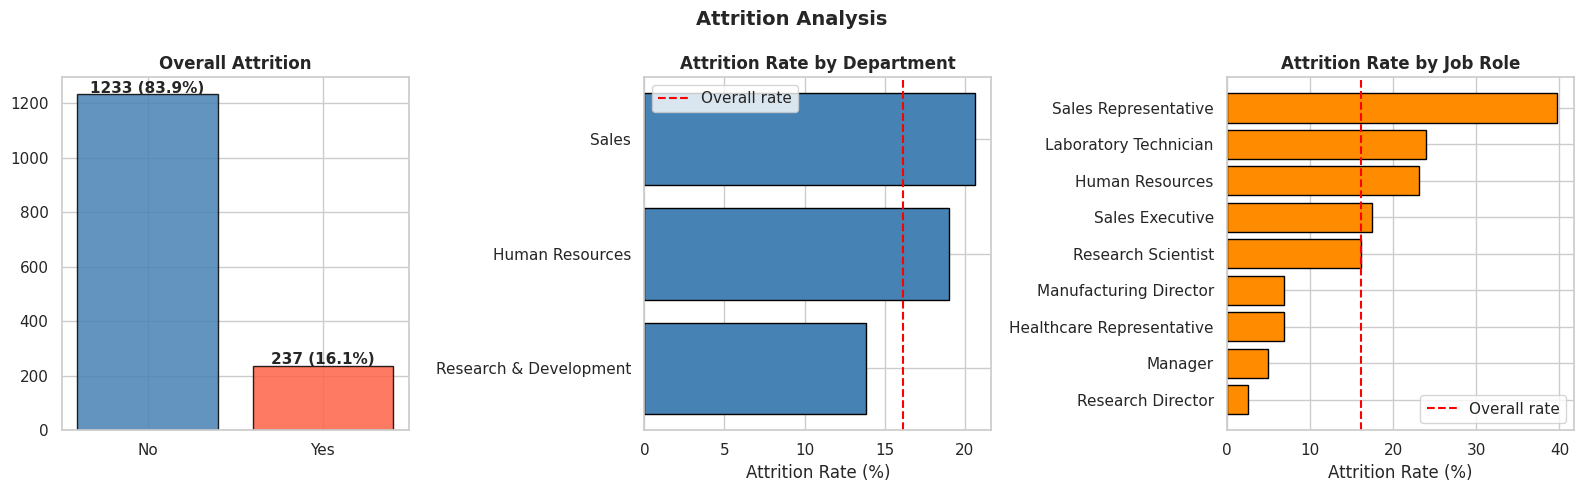

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall attrition
counts = df_raw['Attrition'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue','tomato'],
            edgecolor='black', alpha=0.85)
for i, (k,v) in enumerate(counts.items()):
    axes[0].text(i, v+5, f'{v} ({v/len(df_raw)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Overall Attrition', fontweight='bold')

# By Department
dept_attr = (df_raw.groupby('Department')['Attrition']
             .apply(lambda x: (x=='Yes').mean()*100)
             .sort_values(ascending=True))
axes[1].barh(dept_attr.index, dept_attr.values, color='steelblue', edgecolor='black')
axes[1].axvline(df_raw['Attrition'].eq('Yes').mean()*100,
                color='red', linestyle='--', linewidth=1.5, label='Overall rate')
axes[1].set_title('Attrition Rate by Department', fontweight='bold')
axes[1].set_xlabel('Attrition Rate (%)'); axes[1].legend()

# By JobRole
role_attr = (df_raw.groupby('JobRole')['Attrition']
             .apply(lambda x: (x=='Yes').mean()*100)
             .sort_values(ascending=True))
axes[2].barh(role_attr.index, role_attr.values, color='darkorange', edgecolor='black')
axes[2].axvline(df_raw['Attrition'].eq('Yes').mean()*100,
                color='red', linestyle='--', linewidth=1.5, label='Overall rate')
axes[2].set_title('Attrition Rate by Job Role', fontweight='bold')
axes[2].set_xlabel('Attrition Rate (%)'); axes[2].legend()

plt.suptitle('Attrition Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

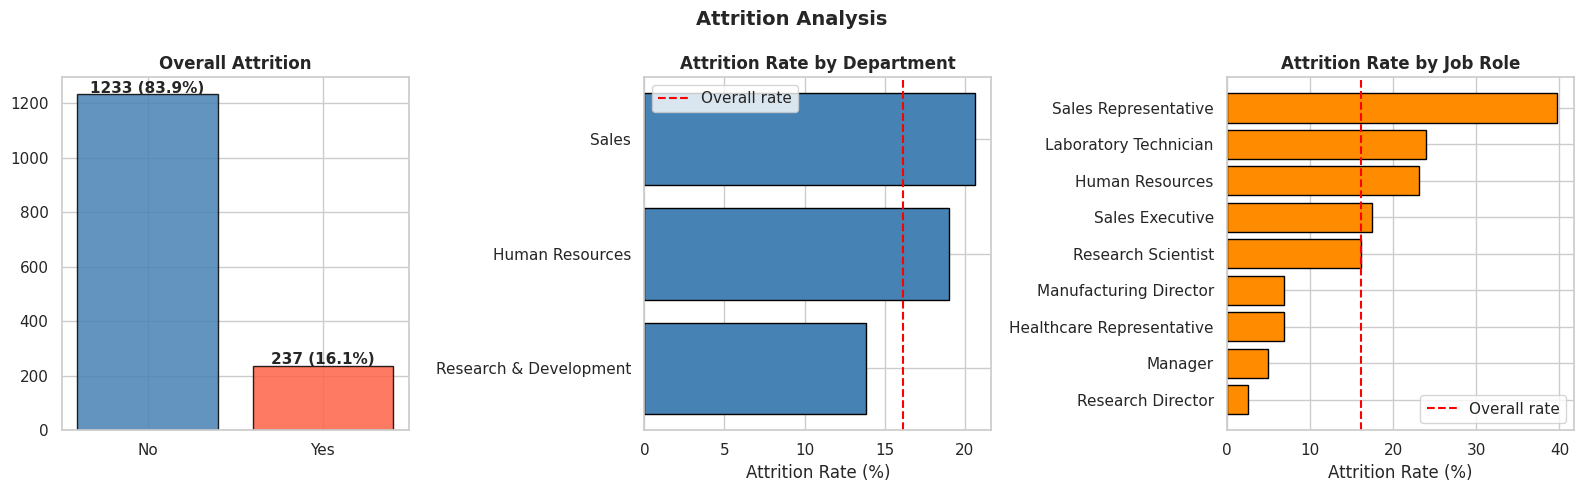

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall attrition
counts = df_raw['Attrition'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue','tomato'],
            edgecolor='black', alpha=0.85)
for i, (k,v) in enumerate(counts.items()):
    axes[0].text(i, v+5, f'{v} ({v/len(df_raw)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Overall Attrition', fontweight='bold')

# By Department
dept_attr = (df_raw.groupby('Department')['Attrition']
             .apply(lambda x: (x=='Yes').mean()*100)
             .sort_values(ascending=True))
axes[1].barh(dept_attr.index, dept_attr.values, color='steelblue', edgecolor='black')
axes[1].axvline(df_raw['Attrition'].eq('Yes').mean()*100,
                color='red', linestyle='--', linewidth=1.5, label='Overall rate')
axes[1].set_title('Attrition Rate by Department', fontweight='bold')
axes[1].set_xlabel('Attrition Rate (%)'); axes[1].legend()

# By JobRole
role_attr = (df_raw.groupby('JobRole')['Attrition']
             .apply(lambda x: (x=='Yes').mean()*100)
             .sort_values(ascending=True))
axes[2].barh(role_attr.index, role_attr.values, color='darkorange', edgecolor='black')
axes[2].axvline(df_raw['Attrition'].eq('Yes').mean()*100,
                color='red', linestyle='--', linewidth=1.5, label='Overall rate')
axes[2].set_title('Attrition Rate by Job Role', fontweight='bold')
axes[2].set_xlabel('Attrition Rate (%)'); axes[2].legend()

plt.suptitle('Attrition Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

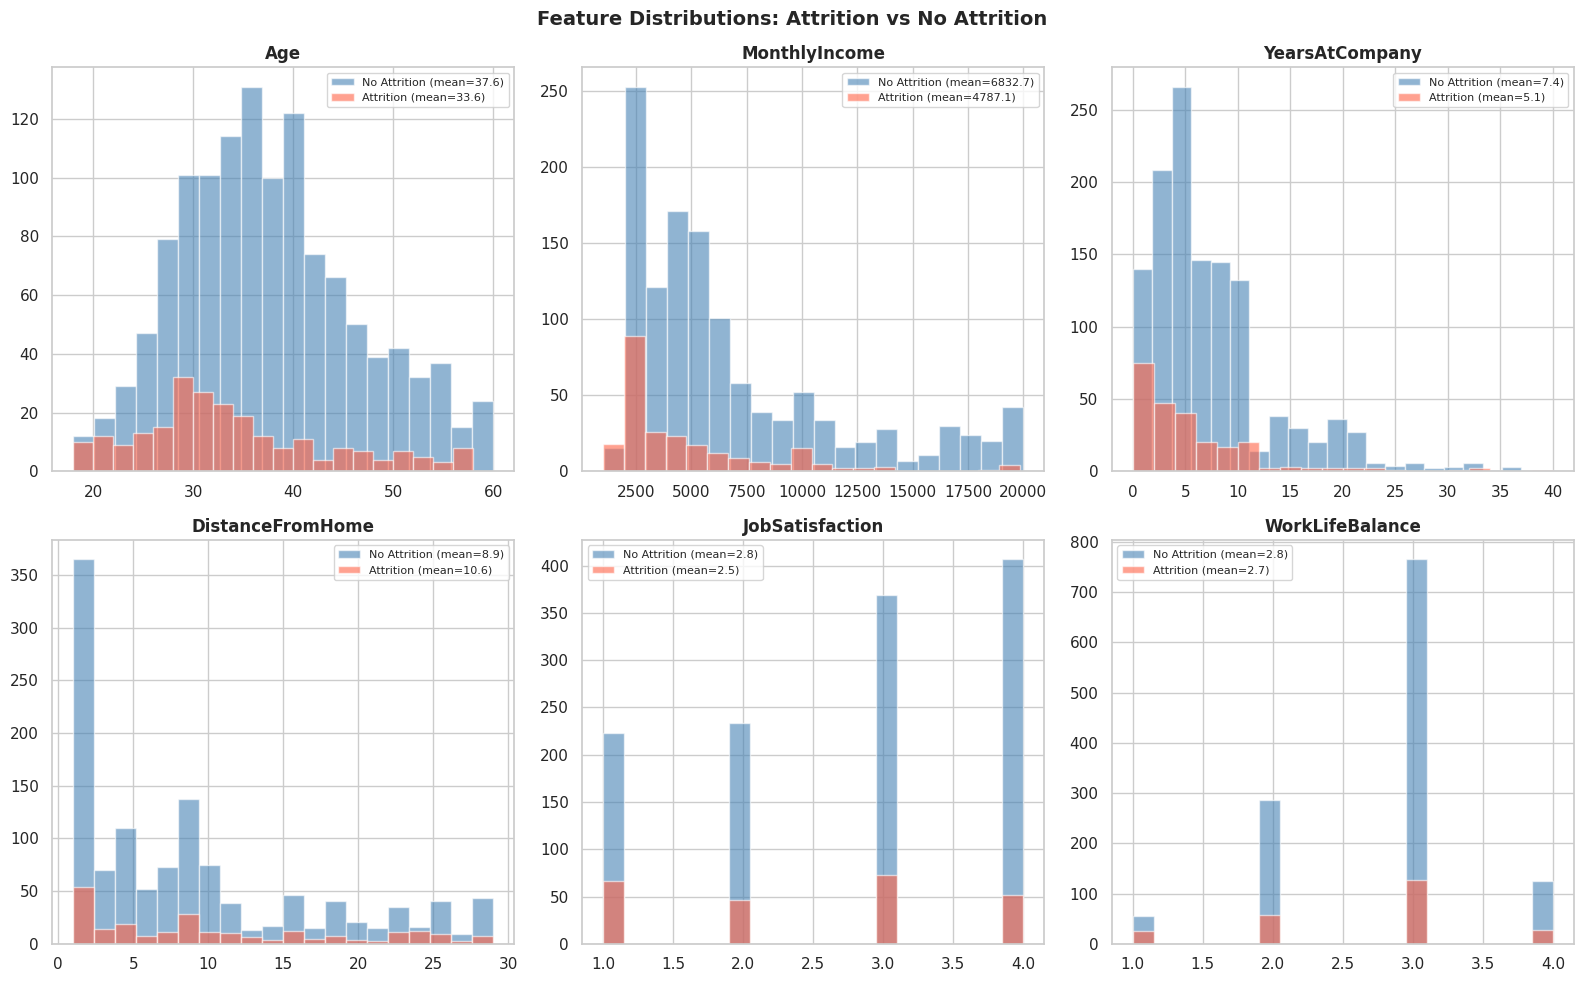

Features where distributions differ most are most predictive.
Notice: employees who leave tend to be younger and earn less.


In [ ]:
# Feature distributions by attrition class
num_features = ['Age','MonthlyIncome','YearsAtCompany',
                'DistanceFromHome','JobSatisfaction','WorkLifeBalance']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    no_attr  = df_raw[df_raw['Attrition']=='No'][col]
    yes_attr = df_raw[df_raw['Attrition']=='Yes'][col]
    axes[i].hist(no_attr,  bins=20, color='steelblue', alpha=0.6,
                 label=f'No Attrition (mean={no_attr.mean():.1f})', edgecolor='white')
    axes[i].hist(yes_attr, bins=20, color='tomato', alpha=0.6,
                 label=f'Attrition (mean={yes_attr.mean():.1f})', edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Attrition vs No Attrition', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('Features where distributions differ most are most predictive.')
print('Notice: employees who leave tend to be younger and earn less.')

## Section 3 - Preprocessing

In [ ]:
df = df_raw.copy()

# Binary target
df['AttritionBinary'] = (df['Attrition'] == 'Yes').astype(int)

# Drop identifier and constant columns
drop_cols = ['EmployeeNumber','EmployeeCount','Over18','StandardHours','Attrition']
df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Encode all categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

TARGET   = 'AttritionBinary'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f'Train:{X_train.shape[0]}  Val:{X_val.shape[0]}  Test:{X_test.shape[0]}')
print(f'Attrition rate - Train:{y_train.mean()*100:.1f}%  Val:{y_val.mean()*100:.1f}%')
print(f'Features used: {len(FEATURES)}')

Train:940  Val:236  Test:294
Attrition rate - Train:16.2%  Val:16.1%
Features used: 30


In [ ]:
cpu_before = psutil.cpu_percent(interval=1)
memory_before = process.memory_info().rss / (1024**2)

training_start = time.time()

## Section 4 - Decision Tree (40 minutes)

A decision tree asks binary questions to split data into progressively purer groups.

**Key challenge:** Without limits, a tree memorises all training data (overfitting).
We tune `max_depth` to find the best generalisation.

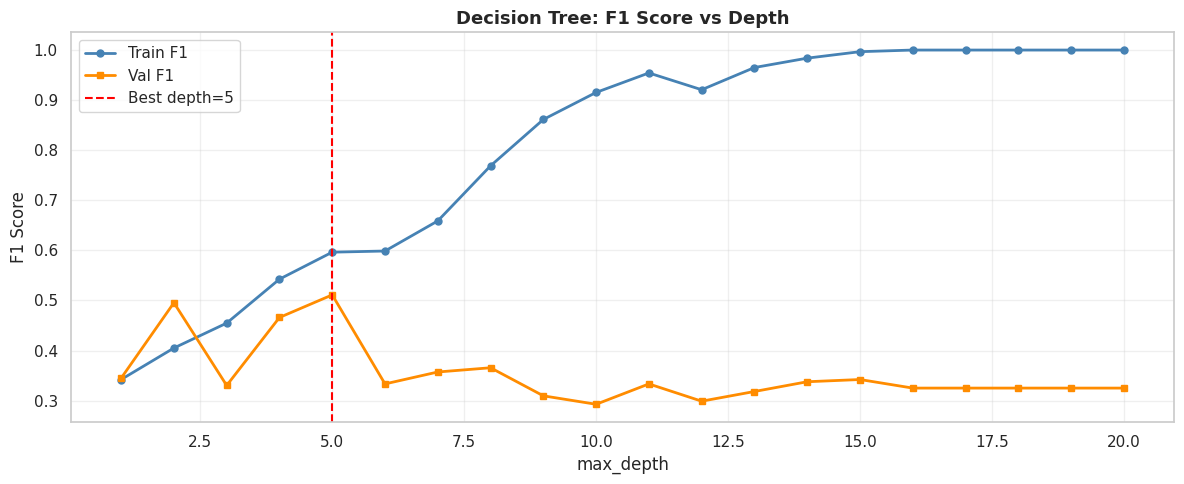

Best depth: 5  (val F1=0.511)
Train F1 increases monotonically - model memorises with more depth
Val F1 peaks then falls - this is overfitting


In [ ]:
# Depth experiment
depths = range(1, 21)
train_f1s, val_f1s = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
    dt.fit(X_train, y_train)
    train_f1s.append(f1_score(y_train, dt.predict(X_train)))
    val_f1s.append(f1_score(y_val,   dt.predict(X_val)))

best_depth = list(depths)[np.argmax(val_f1s)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(depths, train_f1s, 'steelblue', linewidth=2, marker='o', markersize=5, label='Train F1')
ax.plot(depths, val_f1s,   'darkorange', linewidth=2, marker='s', markersize=5, label='Val F1')
ax.axvline(best_depth, color='red', linestyle='--', linewidth=1.5,
           label=f'Best depth={best_depth}')
ax.set_xlabel('max_depth', fontsize=12); ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Decision Tree: F1 Score vs Depth', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Best depth: {best_depth}  (val F1={max(val_f1s):.3f})')
print('Train F1 increases monotonically - model memorises with more depth')
print('Val F1 peaks then falls - this is overfitting')

In [ ]:
training_start = time.time()

best_dt = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42,
    class_weight='balanced'
)

best_dt.fit(X_train, y_train)

training_end = time.time()
dt_training_time = training_end - training_start

cpu_after = psutil.cpu_percent(interval=1)
memory_after = process.memory_info().rss / (1024**2)

prediction_start = time.time()

y_pred_dt = best_dt.predict(X_val)
y_prob_dt = best_dt.predict_proba(X_val)[:,1]

prediction_end = time.time()
dt_prediction_time = prediction_end - prediction_start

dt_model_size = (
    best_dt.tree_.value.nbytes +
    best_dt.tree_.threshold.nbytes +
    best_dt.tree_.feature.nbytes
) / (1024**2)

print("="*60)
print("Decision Tree Performance")
print("="*60)
print(f"Training Time   : {dt_training_time:.4f} sec")
print(f"Prediction Time : {dt_prediction_time:.6f} sec")
print(f"CPU Usage       : {cpu_after:.2f}%")
print(f"Memory Usage    : {memory_after:.2f} MB")
print(f"Model Size      : {dt_model_size:.6f} MB")

Decision Tree Performance
Training Time   : 0.0132 sec
Prediction Time : 0.001056 sec
CPU Usage       : 4.80%
Memory Usage    : 308.02 MB
Model Size      : 0.001434 MB


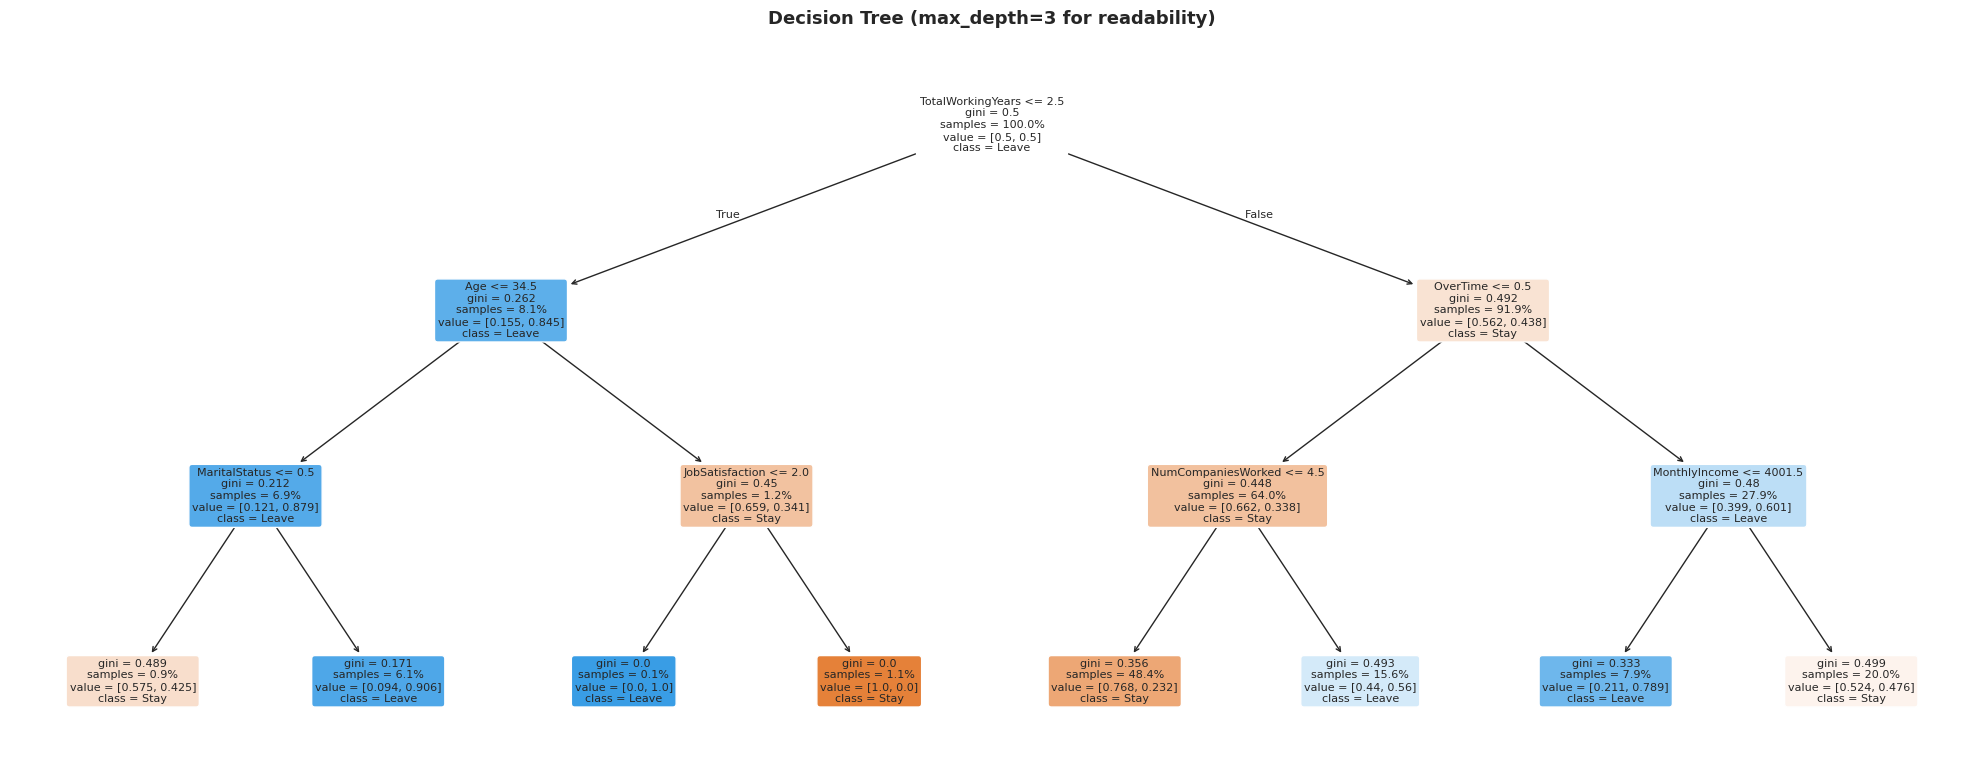

Root split: TotalWorkingYears
Root threshold: 2.50
The root split = most important feature!


In [ ]:
# Train best tree and visualise at depth=3 for readability
best_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42, class_weight='balanced')
best_dt.fit(X_train, y_train)

dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
dt_viz.fit(X_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(dt_viz, feature_names=FEATURES, class_names=['Stay','Leave'],
          filled=True, rounded=True, fontsize=8, proportion=True)
plt.title('Decision Tree (max_depth=3 for readability)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Root split: {FEATURES[best_dt.tree_.feature[0]]}')
print(f'Root threshold: {best_dt.tree_.threshold[0]:.2f}')
print('The root split = most important feature!')

In [ ]:
y_pred_dt = best_dt.predict(X_val)
y_prob_dt = best_dt.predict_proba(X_val)[:,1]
dt_acc = accuracy_score(y_val, y_pred_dt)
dt_f1  = f1_score(y_val, y_pred_dt)
dt_auc = roc_auc_score(y_val, y_prob_dt)

print(f'Decision Tree (depth={best_depth}): Accuracy={dt_acc:.4f}  F1={dt_f1:.4f}  AUC={dt_auc:.4f}')
print()
print(classification_report(y_val, y_pred_dt, target_names=['Stay','Leave']))

Decision Tree (depth=5): Accuracy=0.8136  F1=0.5111  AUC=0.6634

              precision    recall  f1-score   support

        Stay       0.92      0.85      0.88       198
       Leave       0.44      0.61      0.51        38

    accuracy                           0.81       236
   macro avg       0.68      0.73      0.70       236
weighted avg       0.84      0.81      0.82       236



## Section 5 - Random Forest (40 minutes)

Random Forest trains many trees on random data subsets (bootstrap sampling)
and uses a random feature subset at each split to de-correlate the trees.

**Variance reduction:** If B uncorrelated trees each have variance sigma^2,
their average has variance sigma^2/B. With 200 trees: 1/200 of original variance!

**OOB Score:** Each tree only sees ~63% of data. The other ~37% (out-of-bag)
provides a free validation estimate.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200, max_features='sqrt',
    min_samples_leaf=2, oob_score=True,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
y_prob_rf = rf.predict_proba(X_val)[:,1]
rf_acc = accuracy_score(y_val, y_pred_rf)
rf_f1  = f1_score(y_val, y_pred_rf)
rf_auc = roc_auc_score(y_val, y_prob_rf)

print(f'Random Forest: Accuracy={rf_acc:.4f}  F1={rf_f1:.4f}  AUC={rf_auc:.4f}')
print(f'OOB Score: {rf.oob_score_:.4f}  (free internal validation)')
print(f'\nVs Decision Tree: F1 {dt_f1:.4f} -> {rf_f1:.4f}  AUC {dt_auc:.4f} -> {rf_auc:.4f}')

Random Forest: Accuracy=0.8475  F1=0.3077  AUC=0.7731
OOB Score: 0.8585  (free internal validation)

Vs Decision Tree: F1 0.5111 -> 0.3077  AUC 0.6634 -> 0.7731


In [ ]:
training_start = time.time()

rf.fit(X_train, y_train)

training_end = time.time()

rf_training_time = training_end - training_start

cpu_after = psutil.cpu_percent(interval=1)
memory_after = process.memory_info().rss / (1024**2)

prediction_start = time.time()

y_pred_rf = rf.predict(X_val)
y_prob_rf = rf.predict_proba(X_val)[:,1]

prediction_end = time.time()

rf_prediction_time = prediction_end - prediction_start

rf_model_size = sum(
    est.tree_.value.nbytes +
    est.tree_.threshold.nbytes +
    est.tree_.feature.nbytes
    for est in rf.estimators_
) / (1024**2)

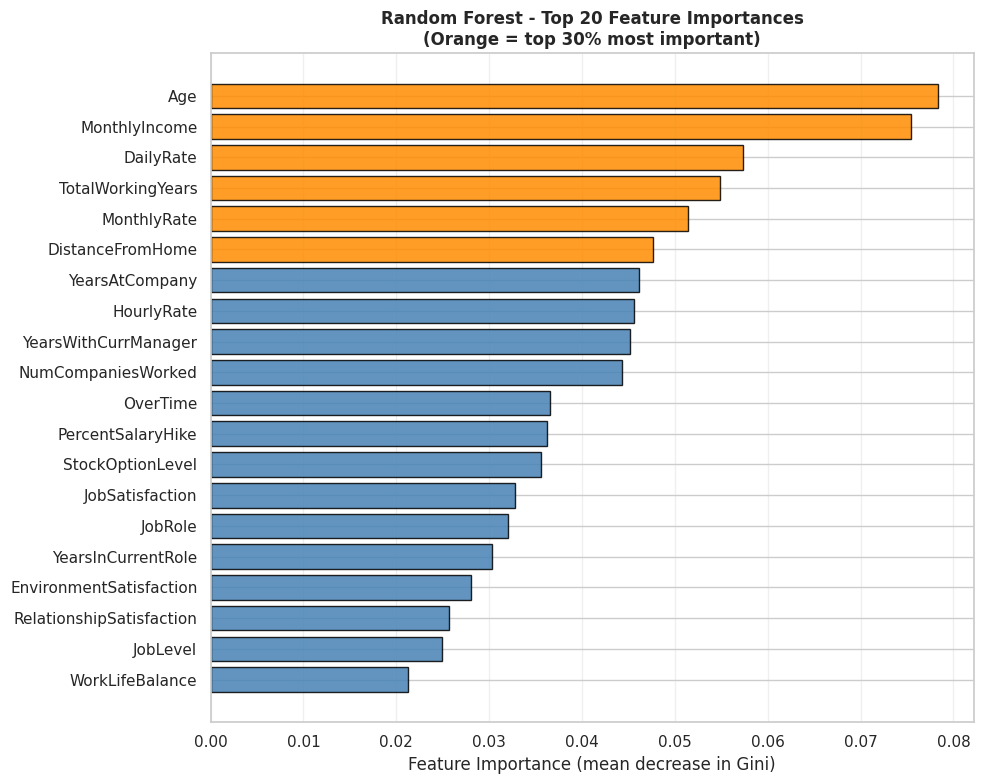

Top 5 features:
  1. Age                           : 0.0783
  2. MonthlyIncome                 : 0.0755
  3. DailyRate                     : 0.0573
  4. TotalWorkingYears             : 0.0548
  5. MonthlyRate                   : 0.0515


In [ ]:
# Feature importance plot
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
top20 = fi.tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['darkorange' if v >= top20.quantile(0.7) else 'steelblue' for v in top20.values]
ax.barh(top20.index, top20.values, color=colors, edgecolor='black', alpha=0.85)
ax.set_xlabel('Feature Importance (mean decrease in Gini)')
ax.set_title('Random Forest - Top 20 Feature Importances\n'
             '(Orange = top 30% most important)', fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

print('Top 5 features:')
for rank, (feat, imp) in enumerate(fi.tail(5).sort_values(ascending=False).items(), 1):
    print(f'  {rank}. {feat:<30}: {imp:.4f}')

## Section 6 - XGBoost (40 minutes)

| | Bagging (RF) | Boosting (XGBoost) |
|---|---|---|
| Training | Parallel | Sequential |
| Each tree sees | Bootstrap sample | All data, residuals |
| Goal | Reduce variance | Reduce bias AND variance |

**Early stopping:** Instead of guessing n_estimators, train until validation stops improving.

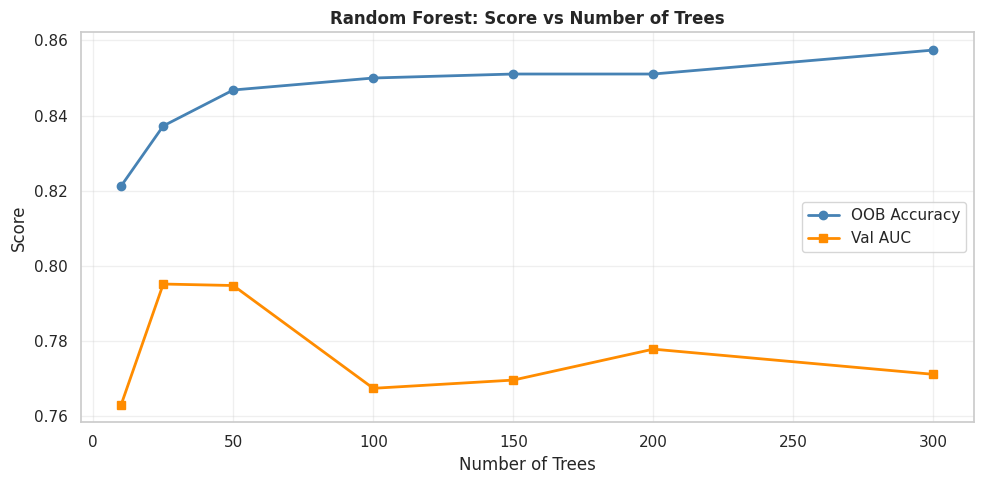

Score improves quickly then plateaus - beyond ~100-150 trees: diminishing returns.


In [ ]:
# n_estimators vs OOB score
n_range = [10, 25, 50, 100, 150, 200, 300]
oob_scores, val_aucs = [], []

for n in n_range:
    rf_temp = RandomForestClassifier(
        n_estimators=n, max_features='sqrt', oob_score=True,
        class_weight='balanced', random_state=42, n_jobs=-1)
    rf_temp.fit(X_train, y_train)
    oob_scores.append(rf_temp.oob_score_)
    val_aucs.append(roc_auc_score(y_val, rf_temp.predict_proba(X_val)[:,1]))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_range, oob_scores, 'steelblue', linewidth=2, marker='o', label='OOB Accuracy')
ax.plot(n_range, val_aucs,  'darkorange', linewidth=2, marker='s', label='Val AUC')
ax.set_xlabel('Number of Trees'); ax.set_ylabel('Score')
ax.set_title('Random Forest: Score vs Number of Trees', fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('Score improves quickly then plateaus - beyond ~100-150 trees: diminishing returns.')

In [ ]:
if not XGBOOST_AVAILABLE:
    print('XGBoost not installed. Run: !pip install xgboost')
else:

    xgb_model = xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric=['logloss', 'auc'],
        early_stopping_rounds=30,
        random_state=42,
        verbosity=0
    )

    training_start = time.time()

    xgb_model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )

    training_end = time.time()
    xgb_training_time = training_end - training_start

    cpu_after = psutil.cpu_percent(interval=1)
    memory_after = process.memory_info().rss / (1024**2)

    prediction_start = time.time()

    y_pred_xgb = xgb_model.predict(X_val)
    y_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

    prediction_end = time.time()
    xgb_prediction_time = prediction_end - prediction_start

    xgb_model.save_model("xgb_model.json")
    xgb_model_size = os.path.getsize("xgb_model.json") / (1024**2)

    best_round = xgb_model.best_iteration

    xgb_acc = accuracy_score(y_val, y_pred_xgb)
    xgb_f1 = f1_score(y_val, y_pred_xgb)
    xgb_auc = roc_auc_score(y_val, y_prob_xgb)

    print("=" * 60)
    print("XGBoost Performance")
    print("=" * 60)
    print(f"Best Iteration  : {best_round}")
    print(f"Accuracy        : {xgb_acc:.4f}")
    print(f"F1 Score        : {xgb_f1:.4f}")
    print(f"AUC             : {xgb_auc:.4f}")
    print(f"Training Time   : {xgb_training_time:.4f} sec")
    print(f"Prediction Time : {xgb_prediction_time:.6f} sec")
    print(f"CPU Usage       : {cpu_after:.2f}%")
    print(f"Memory Usage    : {memory_after:.2f} MB")
    print(f"Model Size      : {xgb_model_size:.6f} MB")

XGBoost Performance
Best Iteration  : 13
Accuracy        : 0.8093
F1 Score        : 0.4944
AUC             : 0.7470
Training Time   : 0.0643 sec
Prediction Time : 0.002712 sec
CPU Usage       : 0.80%
Memory Usage    : 336.02 MB
Model Size      : 0.080658 MB


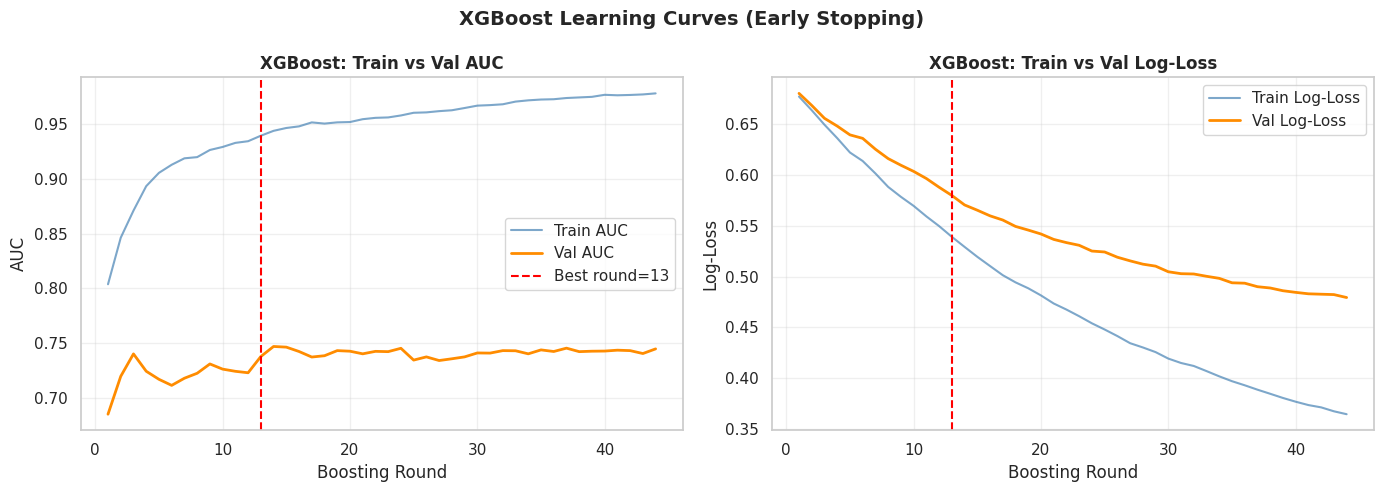

Val AUC peaks then plateaus - early stopping saves us at the peak.
Gap between train and val = overfitting - try lower learning_rate or max_depth.


In [ ]:
if XGBOOST_AVAILABLE:
    results = xgb_model.evals_result()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # AUC curve
    epochs = range(1, len(results['validation_0']['auc'])+1)
    axes[0].plot(epochs, results['validation_0']['auc'],
                 'steelblue', linewidth=1.5, alpha=0.7, label='Train AUC')
    axes[0].plot(epochs, results['validation_1']['auc'],
                 'darkorange', linewidth=2, label='Val AUC')
    axes[0].axvline(best_round, color='red', linestyle='--', linewidth=1.5,
                    label=f'Best round={best_round}')
    axes[0].set_xlabel('Boosting Round'); axes[0].set_ylabel('AUC')
    axes[0].set_title('XGBoost: Train vs Val AUC', fontweight='bold')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Log-loss curve
    axes[1].plot(epochs, results['validation_0']['logloss'],
                 'steelblue', linewidth=1.5, alpha=0.7, label='Train Log-Loss')
    axes[1].plot(epochs, results['validation_1']['logloss'],
                 'darkorange', linewidth=2, label='Val Log-Loss')
    axes[1].axvline(best_round, color='red', linestyle='--', linewidth=1.5)
    axes[1].set_xlabel('Boosting Round'); axes[1].set_ylabel('Log-Loss')
    axes[1].set_title('XGBoost: Train vs Val Log-Loss', fontweight='bold')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle('XGBoost Learning Curves (Early Stopping)', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

    print('Val AUC peaks then plateaus - early stopping saves us at the peak.')
    print('Gap between train and val = overfitting - try lower learning_rate or max_depth.')

## Section 7 - Model Comparison (30 minutes)

In [ ]:
# Build results dictionary
models_eval = {
    'Decision Tree': {'y_pred':y_pred_dt,'y_prob':y_prob_dt,
                      'acc':dt_acc,'f1':dt_f1,'auc':dt_auc,'color':'steelblue'},
    'Random Forest': {'y_pred':y_pred_rf,'y_prob':y_prob_rf,
                      'acc':rf_acc,'f1':rf_f1,'auc':rf_auc,'color':'darkorange'},
}
if XGBOOST_AVAILABLE:
    models_eval['XGBoost'] = {'y_pred':y_pred_xgb,'y_prob':y_prob_xgb,
                               'acc':xgb_acc,'f1':xgb_f1,'auc':xgb_auc,'color':'green'}

baseline_f1 = f1_score(y_val, np.zeros(len(y_val),dtype=int), zero_division=0)

print('=' * 65)
print(f"  {'Model':<22} {'Accuracy':>10} {'F1 Score':>10} {'AUC-ROC':>10}")
print('=' * 65)
print(f"  {'Majority class baseline':<22} {(y_val==0).mean():>10.4f} {baseline_f1:>10.4f} {'0.5000':>10}")
print('-' * 65)
for name, m in models_eval.items():
    best = ' <- BEST' if m['auc'] == max(v['auc'] for v in models_eval.values()) else ''
    print(f"  {name:<22} {m['acc']:>10.4f} {m['f1']:>10.4f} {m['auc']:>10.4f}{best}")
print('=' * 65)
print()
print('Accuracy looks similar for all models because of class imbalance (16% positive).')
print('Always use F1 and AUC for imbalanced classification!')

  Model                    Accuracy   F1 Score    AUC-ROC
  Majority class baseline     0.8390     0.0000     0.5000
-----------------------------------------------------------------
  Decision Tree              0.8136     0.5111     0.6634
  Random Forest              0.8475     0.3077     0.7731 <- BEST
  XGBoost                    0.8093     0.4944     0.7470

Accuracy looks similar for all models because of class imbalance (16% positive).
Always use F1 and AUC for imbalanced classification!


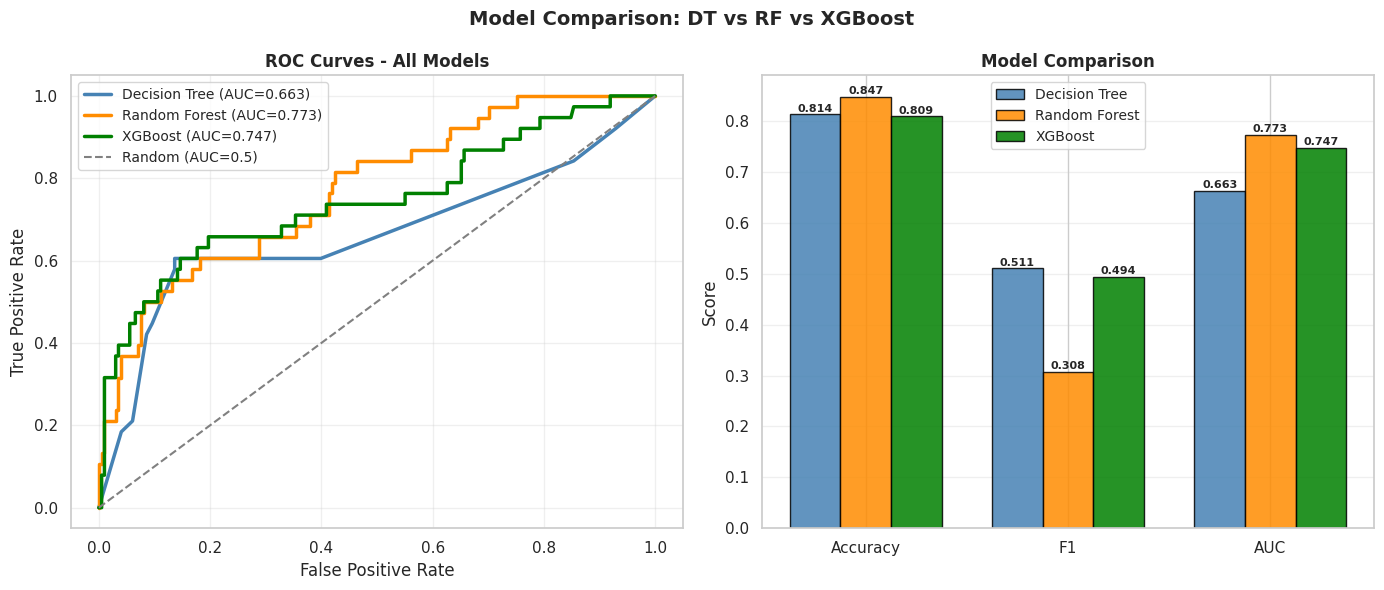

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curves
for name, m in models_eval.items():
    fpr, tpr, _ = roc_curve(y_val, m['y_prob'])
    axes[0].plot(fpr, tpr, linewidth=2.5, color=m['color'],
                 label=f"{name} (AUC={m['auc']:.3f})")
axes[0].plot([0,1],[0,1],'gray',linestyle='--',linewidth=1.5,label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves - All Models', fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# Bar chart comparison
x = np.arange(3)
width = 0.25
for i, (name, m) in enumerate(models_eval.items()):
    vals = [m['acc'], m['f1'], m['auc']]
    bars = axes[1].bar(x+i*width, vals, width, label=name,
                       color=m['color'], edgecolor='black', alpha=0.85)
    for bar, v in zip(bars, vals):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                     f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
axes[1].set_xticks(x+width); axes[1].set_xticklabels(['Accuracy','F1','AUC'])
axes[1].set_ylabel('Score'); axes[1].set_title('Model Comparison', fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('Model Comparison: DT vs RF vs XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

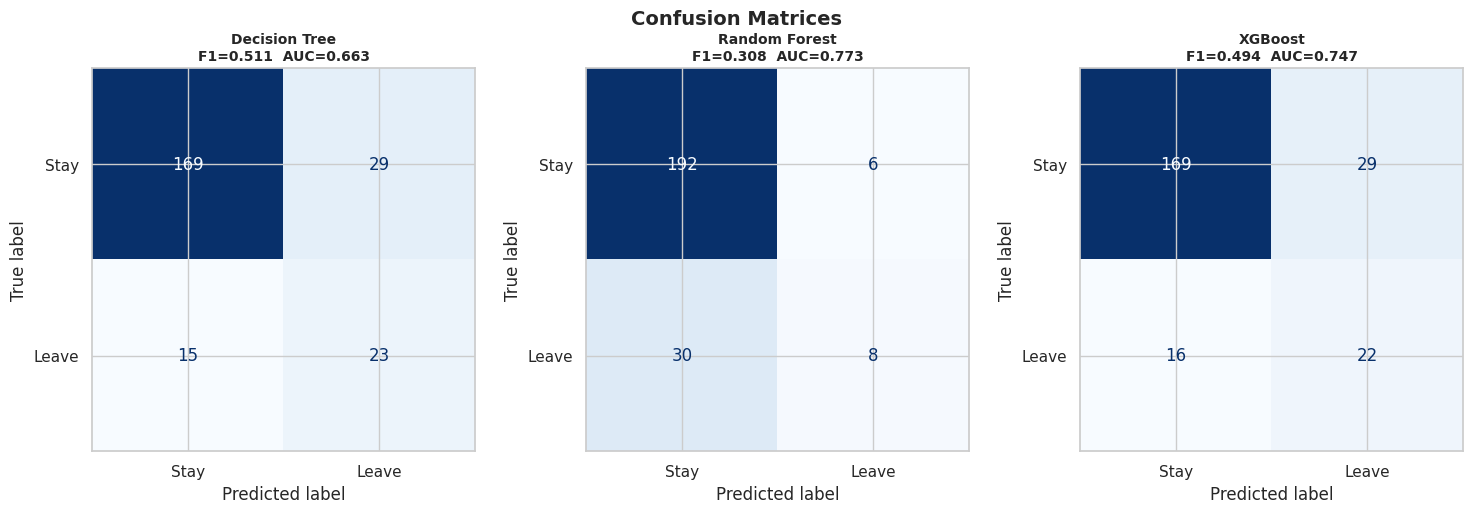

For attrition prediction, False Negatives (FN) are most costly.
FN = employees who WILL leave but we predict they will stay -> missed intervention.
Focus on Recall and F1, not just accuracy.


In [ ]:
# Confusion matrices
n_models = len(models_eval)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5))
if n_models == 1: axes = [axes]

for ax, (name, m) in zip(axes, models_eval.items()):
    cm = confusion_matrix(y_val, m['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Stay','Leave']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    tn,fp,fn,tp = cm.ravel()
    ax.set_title(f"{name}\nF1={m['f1']:.3f}  AUC={m['auc']:.3f}",
                 fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('For attrition prediction, False Negatives (FN) are most costly.')
print('FN = employees who WILL leave but we predict they will stay -> missed intervention.')
print('Focus on Recall and F1, not just accuracy.')

## Section 8 - Business Interpretation

### Which model to deploy?
- **Decision Tree**: most interpretable - explain each prediction as a chain of rules
- **Random Forest**: most robust - less sensitive to training data noise
- **XGBoost**: best performance but harder to explain

### How to use this model in practice
1. Score all employees monthly - get their attrition probability
2. Flag employees above a threshold (e.g., 60% probability of leaving)
3. Share the flag + top risk factors with HR managers
4. HR takes action: salary review, promotion, flexible hours, mentoring
5. Track impact: compare 6-month attrition for flagged vs non-flagged groups

### Limitations
- Model trained on historical data - patterns may change over time
- Correlation is not causation - investigate WHY before acting
- Employee privacy concerns must be addressed before deployment

In [ ]:
print('=' * 60)
print('  TOP BUSINESS INSIGHTS FROM FEATURE IMPORTANCE')
print('=' * 60)
fi_sorted = fi.sort_values(ascending=False)
interpretations = {
    'OverTime'          : 'Overworked employees leave - review workload',
    'MonthlyIncome'     : 'Underpaid employees leave - benchmark salaries',
    'Age'               : 'Younger employees have higher attrition',
    'TotalWorkingYears' : 'Early-career employees leave more often',
    'YearsAtCompany'    : 'Low-tenure employees are at risk',
    'JobLevel'          : 'Lower levels leave more - create promotion paths',
    'StockOptionLevel'  : 'Better equity = lower attrition',
    'DistanceFromHome'  : 'Long commutes predict attrition',
    'JobSatisfaction'   : 'Unsatisfied employees leave',
    'MaritalStatus'     : 'Single employees are more mobile',
}
for rank, (feat, imp) in enumerate(fi_sorted.head(10).items(), 1):
    interp = interpretations.get(feat, 'Investigate with domain experts')
    print(f'  {rank:2d}. {feat:<28} ({imp:.4f}) - {interp}')

  TOP BUSINESS INSIGHTS FROM FEATURE IMPORTANCE
   1. Age                          (0.0783) - Younger employees have higher attrition
   2. MonthlyIncome                (0.0755) - Underpaid employees leave - benchmark salaries
   3. DailyRate                    (0.0573) - Investigate with domain experts
   4. TotalWorkingYears            (0.0548) - Early-career employees leave more often
   5. MonthlyRate                  (0.0515) - Investigate with domain experts
   6. DistanceFromHome             (0.0476) - Long commutes predict attrition
   7. YearsAtCompany               (0.0461) - Low-tenure employees are at risk
   8. HourlyRate                   (0.0456) - Investigate with domain experts
   9. YearsWithCurrManager         (0.0451) - Investigate with domain experts
  10. NumCompaniesWorked           (0.0443) - Investigate with domain experts


In [ ]:
print('=' * 65)
print('  DAY 2 NOTEBOOK - FINAL RESULTS SUMMARY')
print('=' * 65)
print(f'  Dataset: IBM HR Analytics Employee Attrition')
print(f'  Train:{len(y_train)}  Val:{len(y_val)}  Test:{len(y_test)}')
print(f'  Attrition rate: {y_train.mean()*100:.1f}% (imbalanced - use F1/AUC)')
print()
print(f"  {'Model':<22} {'F1 Score':>10} {'AUC-ROC':>10}")
print('  ' + '-'*45)
print(f"  {'Majority class baseline':<22} {baseline_f1:>10.4f} {'0.5000':>10}")
for name, m in models_eval.items():
    print(f"  {name:<22} {m['f1']:>10.4f} {m['auc']:>10.4f}")
print('=' * 65)
print()
print('Key lessons:')
print('  1. A single DT overfits at high depth - always tune max_depth')
print('  2. Random Forest is much more stable and handles noise well')
print('  3. XGBoost with early stopping finds optimal n_estimators automatically')
print('  4. Feature importance tells you WHAT matters, not WHY')
print('  5. For imbalanced data: F1 and AUC > accuracy')
print()
print('Next: Day 3 - SVM, KNN, Naive Bayes + Unsupervised Learning')

FINAL PERFORMANCE SUMMARY
Decision Tree Training Time        : 0.0132 sec
Decision Tree Prediction Time      : 0.001056 sec
Decision Tree Model Size           : 0.0014 MB
------------------------------------------------------------------------------------------
Random Forest Training Time        : 0.7073 sec
Random Forest Prediction Time      : 0.158512 sec
Random Forest Model Size           : 1.2242 MB
------------------------------------------------------------------------------------------
XGBoost Training Time              : 0.0643 sec
XGBoost Prediction Time            : 0.002712 sec
XGBoost Model Size                 : 0.0807 MB
------------------------------------------------------------------------------------------
CPU Usage                          : 0.80%
Memory Usage                       : 336.02 MB


In [ ]:
print("="*90)
print("FINAL PERFORMANCE SUMMARY")
print("="*90)

print(f"{'Decision Tree Training Time':35}: {dt_training_time:.4f} sec")
print(f"{'Decision Tree Prediction Time':35}: {dt_prediction_time:.6f} sec")
print(f"{'Decision Tree Model Size':35}: {dt_model_size:.4f} MB")

print("-"*90)

print(f"{'Random Forest Training Time':35}: {rf_training_time:.4f} sec")
print(f"{'Random Forest Prediction Time':35}: {rf_prediction_time:.6f} sec")
print(f"{'Random Forest Model Size':35}: {rf_model_size:.4f} MB")

print("-"*90)

if XGBOOST_AVAILABLE:
    print(f"{'XGBoost Training Time':35}: {xgb_training_time:.4f} sec")
    print(f"{'XGBoost Prediction Time':35}: {xgb_prediction_time:.6f} sec")
    print(f"{'XGBoost Model Size':35}: {xgb_model_size:.4f} MB")

print("-"*90)

print(f"{'CPU Usage':35}: {cpu_after:.2f}%")
print(f"{'Memory Usage':35}: {memory_after:.2f} MB")

print("="*90)

FINAL PERFORMANCE SUMMARY
Decision Tree Training Time        : 0.0132 sec
Decision Tree Prediction Time      : 0.001056 sec
Decision Tree Model Size           : 0.0014 MB
------------------------------------------------------------------------------------------
Random Forest Training Time        : 0.7073 sec
Random Forest Prediction Time      : 0.158512 sec
Random Forest Model Size           : 1.2242 MB
------------------------------------------------------------------------------------------
XGBoost Training Time              : 0.0643 sec
XGBoost Prediction Time            : 0.002712 sec
XGBoost Model Size                 : 0.0807 MB
------------------------------------------------------------------------------------------
CPU Usage                          : 0.80%
Memory Usage                       : 336.02 MB
